In [35]:
from pydoc import describe

from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split    # 分割数据集的
from sklearn.neighbors import KNeighborsClassifier      # KNN 算法
from sklearn.preprocessing import StandardScaler        # 数据标准化的
from sklearn.metrics import accuracy_score              # 模型评估 ，测评模型正确性

    ![](https://cdn.jsdelivr.net/gh/TokeyTuT/my-image-storage@main/img/20260423165410540.png)
![](https://cdn.jsdelivr.net/gh/TokeyTuT/my-image-storage@main/img/20260423165320737.png)

In [3]:
iris_data = load_iris()
# 查看数据集
print(iris_data)

print(type(iris_data)) # <class 'sklearn.utils._bunch.Bunch'>

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [7]:
# 查看鸢尾花的键
print(iris_data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [12]:
print(iris_data.data[:5])
print(iris_data.target[:5]) #
print(iris_data.target_names[:5]) # ['setosa' 'versicolor' 'virginica']

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]
['setosa' 'versicolor' 'virginica']


In [21]:
# 讲数据集转为 DataFrame 类型
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)

In [23]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [24]:
# 给 df 对象新增标签列
iris_df['label'] = iris_data.target

In [26]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

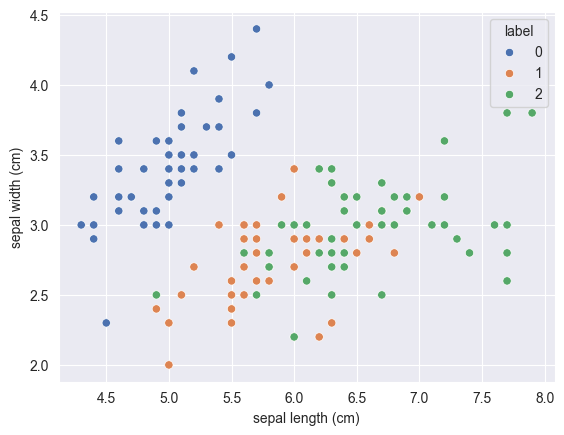

In [30]:
# 绘制散点图
sns.scatterplot(data=iris_df,x='sepal length (cm)',y = 'sepal width (cm)',hue='label',palette='deep')

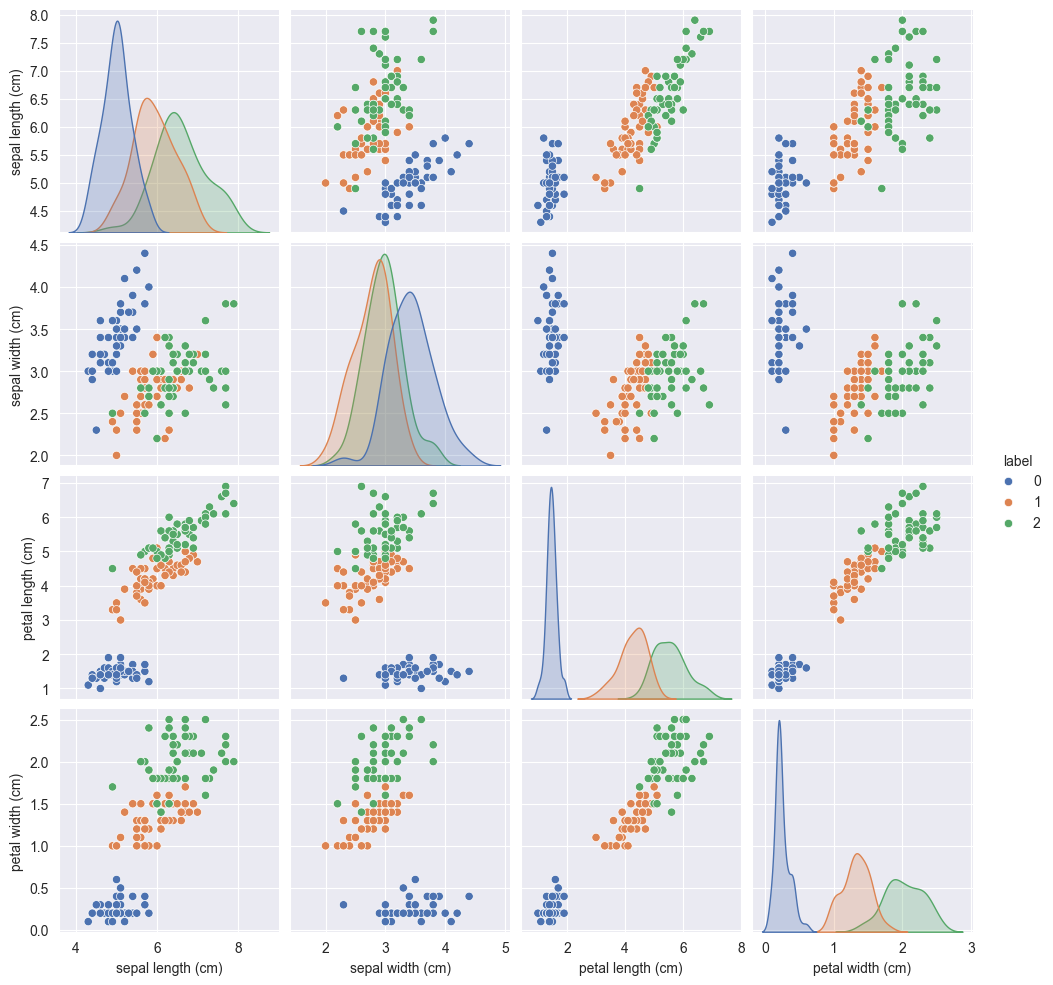

In [32]:
sns.pairplot(data=iris_df,hue='label',palette='deep')

In [34]:
# 数据集的预处理，对标签进行按照 8：2的比例，划分训练集和测试集

x_train,x_test,y_train,y_test = train_test_split(iris_data.data, # 数据
                 iris_data.target, # 标签
                 test_size=0.2, # 训练集和测试集的比例
                 random_state=115)  # 随机数种子

In [36]:
print(f"训练集的特征:{x_train}")
print(f"训练集的标签:{y_train}")

训练集的特征:[[5.8 2.7 5.1 1.9]
 [6.3 2.9 5.6 1.8]
 [6.4 3.2 5.3 2.3]
 [6.5 2.8 4.6 1.5]
 [4.9 2.5 4.5 1.7]
 [5.4 3.4 1.7 0.2]
 [6.  2.9 4.5 1.5]
 [6.4 2.8 5.6 2.1]
 [5.  3.2 1.2 0.2]
 [5.1 3.3 1.7 0.5]
 [4.3 3.  1.1 0.1]
 [7.7 3.  6.1 2.3]
 [7.2 3.2 6.  1.8]
 [5.8 2.7 3.9 1.2]
 [5.4 3.9 1.3 0.4]
 [7.1 3.  5.9 2.1]
 [5.1 3.4 1.5 0.2]
 [5.6 2.7 4.2 1.3]
 [4.8 3.4 1.6 0.2]
 [5.7 3.  4.2 1.2]
 [7.7 3.8 6.7 2.2]
 [5.7 4.4 1.5 0.4]
 [7.  3.2 4.7 1.4]
 [4.9 3.  1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [6.6 2.9 4.6 1.3]
 [6.2 2.2 4.5 1.5]
 [6.3 3.3 4.7 1.6]
 [7.2 3.  5.8 1.6]
 [6.  3.4 4.5 1.6]
 [5.5 2.4 3.8 1.1]
 [5.2 3.4 1.4 0.2]
 [6.7 2.5 5.8 1.8]
 [6.  2.7 5.1 1.6]
 [4.8 3.  1.4 0.3]
 [7.6 3.  6.6 2.1]
 [5.5 2.5 4.  1.3]
 [4.9 3.1 1.5 0.2]
 [4.9 2.4 3.3 1. ]
 [5.4 3.  4.5 1.5]
 [4.9 3.6 1.4 0.1]
 [5.2 4.1 1.5 0.1]
 [6.3 2.5 5.  1.9]
 [6.4 2.7 5.3 1.9]
 [5.  2.  3.5 1. ]
 [5.6 2.9 3.6 1.3]
 [5.4 3.9 1.7 0.4]
 [4.6 3.6 1.  0.2]
 [5.9 3.2 4.8 1.8]
 [7.9 3.8 6.4 2. ]
 [6.4 3.1 5.5 1.8]
 [5.7 2.9 4.2 1.3]
 [6. 

In [ ]:
# 定义函数，实现鸢尾花案例，见另一 Python 文件